In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [ ]:
file = "/content/Bus_Ridership_20250302.csv"
df = pd.read_csv(file)
df.head()

,Row ID,Month,Calendar Year,Fiscal Year,Month Date,Route,Riders
0,1,Jul,2013,FY13-14,07/01/2013,108,"1,606"
1,2,Jul,2013,FY13-14,07/01/2013,112,"35,972"
2,3,Jul,2013,FY13-14,07/01/2013,120,"8,907"
3,4,Jul,2013,FY13-14,07/01/2013,128,"8,924"
4,5,Jul,2013,FY13-14,07/01/2013,136,"12,722"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2689 entries, 0 to 2688
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Row ID         2689 non-null   int64 
 1   Month          2689 non-null   object
 2   Calendar Year  2689 non-null   int64 
 3   Fiscal Year    2689 non-null   object
 4   Month Date     2689 non-null   object
 5   Route          2689 non-null   object
 6   Riders         2689 non-null   object
dtypes: int64(2), object(5)
memory usage: 147.2+ KB


In [ ]:
df["Month"].unique()
df["Calendar Year"].unique()
df["Month Date"].unique()
# df["Fiscal Year"].unique()
# df["Route"].unique()

array(['07/01/2013', '08/01/2013', '09/01/2013', '10/01/2013',
       '11/01/2013', '12/01/2013', '01/01/2014', '02/01/2014',
       '03/01/2014', '04/01/2014', '05/01/2014', '06/01/2014',
       '07/01/2014', '08/01/2014', '09/01/2014', '10/01/2014',
       '11/01/2014', '12/01/2014', '01/01/2015', '02/01/2015',
       '03/01/2015', '04/01/2015', '05/01/2015', '06/01/2015',
       '07/01/2015', '08/01/2015', '09/01/2015', '10/01/2015',
       '11/01/2015', '12/01/2015', '01/01/2016', '02/01/2016',
       '03/01/2016', '04/01/2016', '05/01/2016', '06/01/2016',
       '07/01/2016', '08/01/2016', '09/01/2016', '10/01/2016',
       '11/01/2016', '12/01/2016', '01/01/2017', '02/01/2017',
       '03/01/2017', '04/01/2017', '05/01/2017', '06/01/2017',
       '07/01/2017', '08/01/2017', '09/01/2017', '10/01/2017',
       '11/01/2017', '12/01/2017', '01/01/2018', '02/01/2018',
       '03/01/2018', '04/01/2018', '05/01/2018', '06/01/2018',
       '07/01/2018', '08/01/2018', '09/01/2018', '10/01

In [ ]:
df["Riders"].unique()

array(['1,606', '35,972', '8,907', ..., '8,415', '350', '24,800'],
      dtype=object)

In [ ]:
df["Route"].value_counts()

,count
Route,
108,137
40,137
96,137
77,137
112,137
533,137
531,137
45,137
61,137


In [ ]:
df_filtered = df[~df["Route"].isin(["AZ Ave Link", "Main St Link"])]

In [ ]:
df_filtered["Route"].value_counts()

,count
Route,
108,137
45,137
96,137
77,137
61,137
112,137
533,137
531,137
40,137


In [ ]:
df_filtered["Route"] = df["Route"].replace({"DBuzz": "Buzz", "Dbuzz": "Buzz", "FBuzz": "Buzz", "Fbuzz": "Buzz"})


<ipython-input-9-e3a754de25f8>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Route"] = df["Route"].replace({"DBuzz": "Buzz", "Dbuzz": "Buzz", "FBuzz": "Buzz", "Fbuzz": "Buzz"})


In [ ]:
df_filtered["Route"].value_counts()

,count
Route,
Buzz,153
108,137
45,137
96,137
77,137
61,137
533,137
112,137
531,137


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2605 entries, 0 to 2688
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Row ID         2605 non-null   int64 
 1   Month          2605 non-null   object
 2   Calendar Year  2605 non-null   int64 
 3   Fiscal Year    2605 non-null   object
 4   Month Date     2605 non-null   object
 5   Route          2605 non-null   object
 6   Riders         2605 non-null   object
dtypes: int64(2), object(5)
memory usage: 162.8+ KB


In [ ]:
df_filtered["date_column"] = pd.to_datetime(df_filtered["Month Date"], format="%m/%d/%Y")
df_filtered["Month"] = df_filtered["date_column"].dt.month

<ipython-input-12-6dba609d6812>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["date_column"] = pd.to_datetime(df_filtered["Month Date"], format="%m/%d/%Y")
<ipython-input-12-6dba609d6812>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Month"] = df_filtered["date_column"].dt.month


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2605 entries, 0 to 2688
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2605 non-null   int64         
 1   Month          2605 non-null   int32         
 2   Calendar Year  2605 non-null   int64         
 3   Fiscal Year    2605 non-null   object        
 4   Month Date     2605 non-null   object        
 5   Route          2605 non-null   object        
 6   Riders         2605 non-null   object        
 7   date_column    2605 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int32(1), int64(2), object(4)
memory usage: 173.0+ KB


In [ ]:
# df_filtered = df_filtered.drop(columns=["column1", "column2"])

In [ ]:
df_filtered["Riders"] = df_filtered["Riders"].str.replace(",", "")
df_filtered["Riders"] = df_filtered["Riders"].astype(int)

<ipython-input-15-0a653478e226>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Riders"] = df_filtered["Riders"].str.replace(",", "")
<ipython-input-15-0a653478e226>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["Riders"] = df_filtered["Riders"].astype(int)


In [ ]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2605 entries, 0 to 2688
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2605 non-null   int64         
 1   Month          2605 non-null   int32         
 2   Calendar Year  2605 non-null   int64         
 3   Fiscal Year    2605 non-null   object        
 4   Month Date     2605 non-null   object        
 5   Route          2605 non-null   object        
 6   Riders         2605 non-null   int64         
 7   date_column    2605 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int32(1), int64(3), object(3)
memory usage: 173.0+ KB


In [ ]:
df_filtered.to_csv("Cleaned_bus_ridership_data.csv")

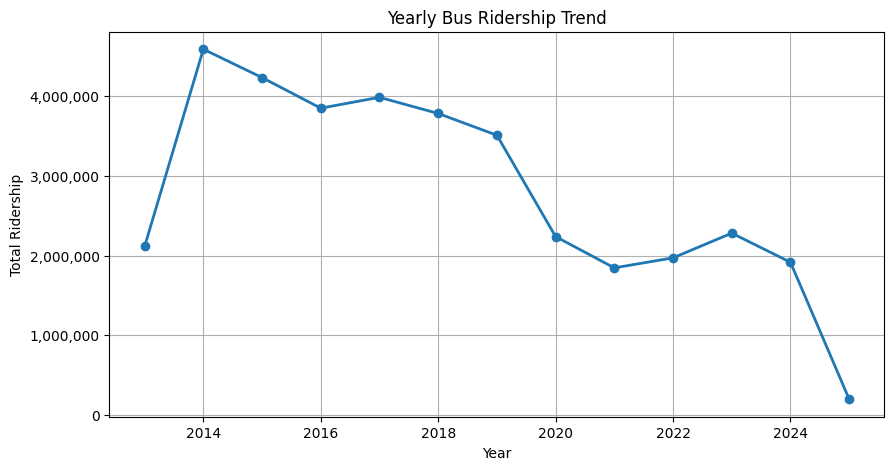

In [ ]:
#Yearly ridership trends

yearly_ridership = df_filtered.groupby("Calendar Year")["Riders"].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_ridership.index, yearly_ridership.values, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Year")
plt.ylabel("Total Ridership")
plt.title("Yearly Bus Ridership Trend")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()



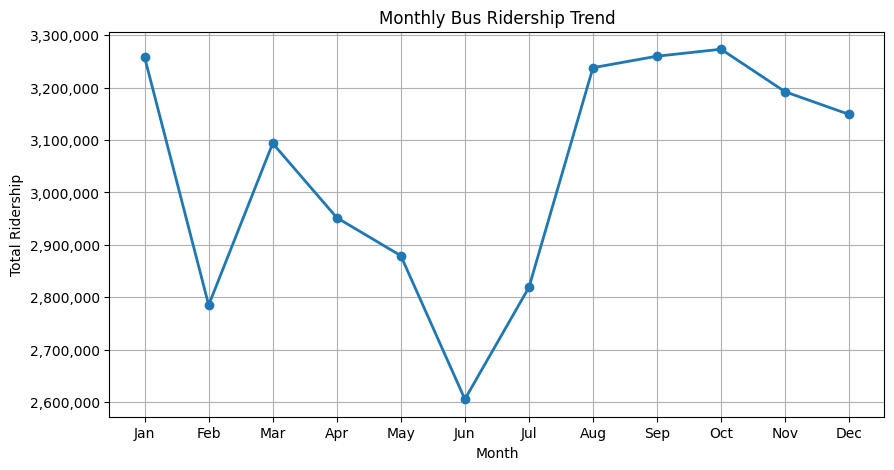

In [ ]:
#Monthly Ridership trends
monthly_ridership = df_filtered.groupby("Month")["Riders"].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_ridership.index, monthly_ridership.values, marker='o', linestyle='-', linewidth=2)
plt.xlabel("Month")
plt.ylabel("Total Ridership")
plt.title("Monthly Bus Ridership Trend")
plt.xticks(range(1, 13),
           ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()

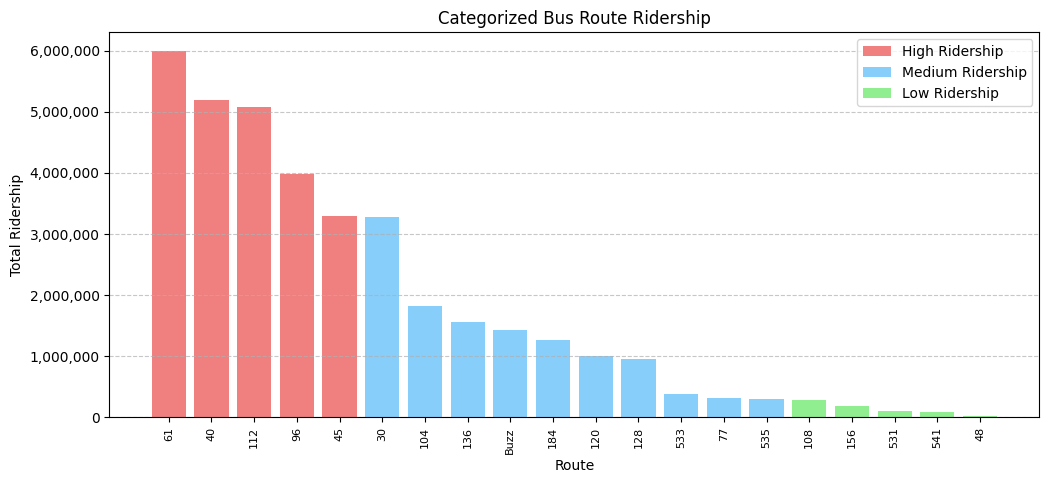

In [ ]:
route_performance = df_filtered.groupby("Route")["Riders"].sum().reset_index()

# Sort routes by total ridership (mainly for better readability)
route_performance = route_performance.sort_values(by="Riders", ascending=False)

#Categorizing all the Routes
q1 = route_performance["Riders"].quantile(0.25)  # Bottom 25%
q3 = route_performance["Riders"].quantile(0.75)  # Top 25%

route_performance["Category"] = route_performance["Riders"].apply(
    lambda x: "High Ridership" if x >= q3 else ("Low Ridership" if x <= q1 else "Medium Ridership")
)

#Categorized Ridership
plt.figure(figsize=(12, 5))
# colors = {"High Ridership": "green", "Medium Ridership": "blue", "Low Ridership": "red"}
# colors = {"High Ridership": "#00FF00", "Medium Ridership": "#00FFFF", "Low Ridership": "#FF00FF"}
# colors = {"High Ridership": "teal", "Medium Ridership": "cornflowerblue", "Low Ridership": "indigo"}
colors = {"High Ridership": "lightcoral", "Medium Ridership": "lightskyblue", "Low Ridership": "lightgreen"}
# colors = {"High Ridership": "darkorange", "Medium Ridership": "royalblue", "Low Ridership": "crimson"}


for category in ["High Ridership", "Medium Ridership", "Low Ridership"]:
    subset = route_performance[route_performance["Category"] == category]
    plt.bar(subset["Route"], subset["Riders"], label=category, color=colors[category])

plt.xlabel("Route")
plt.ylabel("Total Ridership")
plt.title("Categorized Bus Route Ridership")
plt.xticks(rotation=90, fontsize=8)
plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()


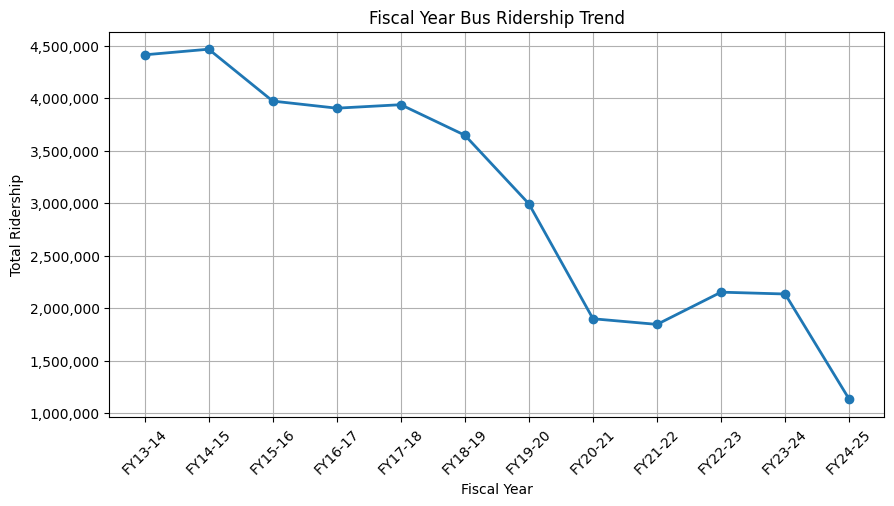

In [ ]:
fiscal_year_ridership = df_filtered.groupby("Fiscal Year")["Riders"].sum().reset_index()

#Year-over-Year Percentage Change
fiscal_year_ridership["YoY Percentage Change"] = fiscal_year_ridership["Riders"].pct_change() * 100

#Fiscal Year Ridership Trend
plt.figure(figsize=(10, 5))
plt.plot(fiscal_year_ridership["Fiscal Year"], fiscal_year_ridership["Riders"], marker='o', linestyle='-', linewidth=2)
plt.xlabel("Fiscal Year")
plt.ylabel("Total Ridership")
plt.title("Fiscal Year Bus Ridership Trend")
plt.xticks(rotation=45)
plt.grid(True)
plt.gca().yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.show()



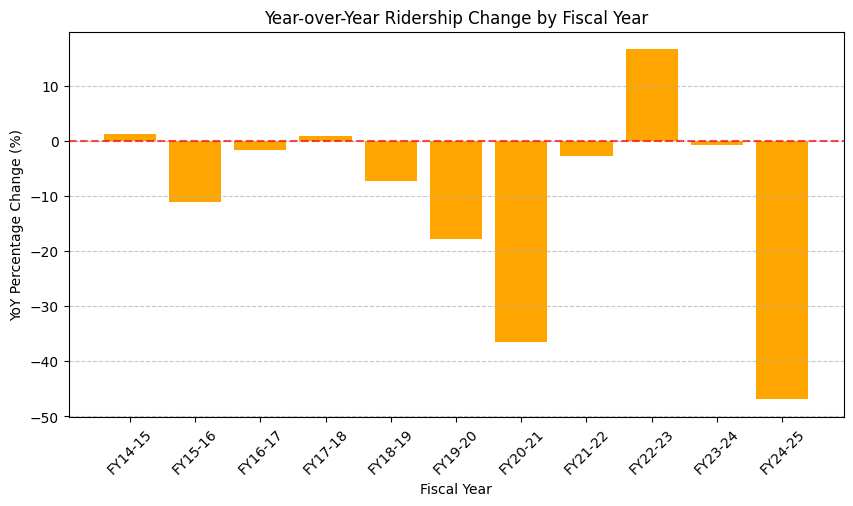

In [ ]:
#Percentage Change
plt.figure(figsize=(10, 5))
plt.bar(fiscal_year_ridership["Fiscal Year"], fiscal_year_ridership["YoY Percentage Change"], color="orange")
plt.axhline(0, color='red', linestyle='--', alpha=0.7)  #Reference line at 0% change
plt.xlabel("Fiscal Year")
plt.ylabel("YoY Percentage Change (%)")
plt.title("Year-over-Year Ridership Change by Fiscal Year")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle="--", alpha=0.7)
plt.show()